<a href="https://colab.research.google.com/github/vaishnavighadge2103/vaishnavi/blob/main/task_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

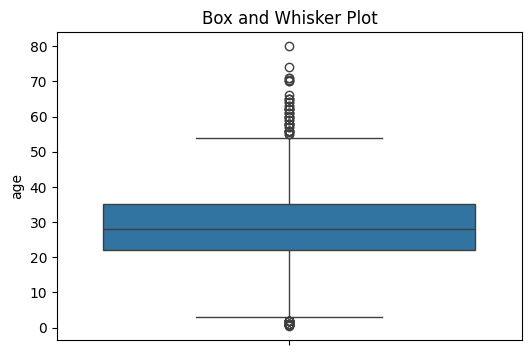

Q1 = 22.0
Q3 = 35.0
IQR = 13.0
Lower Limit = 2.5
Upper Limit = 54.5

Outliers using Tukey's Method:
       age
7     2.00
11   58.00
15   55.00
16    2.00
33   66.00
..     ...
827   1.00
829  62.00
831   0.83
851  74.00
879  56.00

[66 rows x 1 columns]

Z-Score:
    age  Age_ZScore
0  22.0   -0.565736
1  38.0    0.663861
2  26.0   -0.258337
3  35.0    0.433312
4  35.0    0.433312

Outliers using Z-Score:
      age  Age_ZScore
96   71.0    3.199906
116  70.5    3.161481
493  71.0    3.199906
630  80.0    3.891554
672  70.0    3.123056
745  70.0    3.123056
851  74.0    3.430455


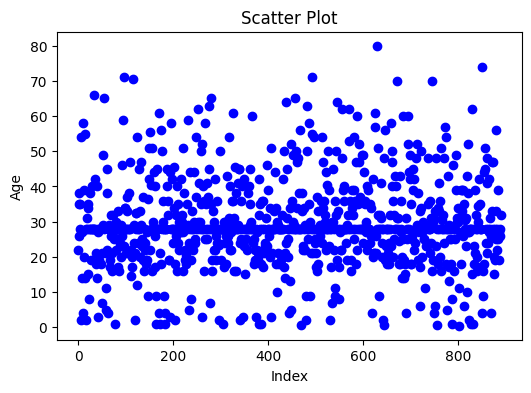

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

df = sns.load_dataset("titanic")

df["age"] = df["age"].fillna(df["age"].median())

plt.figure(figsize=(6,4))
sns.boxplot(y=df["age"])
plt.title("Box and Whisker Plot")
plt.show()

Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower Limit =", lower)
print("Upper Limit =", upper)

outliers = df[(df["age"] < lower) | (df["age"] > upper)]
print("\nOutliers using Tukey's Method:")
print(outliers[["age"]])

df["Age_ZScore"] = zscore(df["age"])

print("\nZ-Score:")
print(df[["age", "Age_ZScore"]].head())

z_outliers = df[abs(df["Age_ZScore"]) > 3]
print("\nOutliers using Z-Score:")
print(z_outliers[["age", "Age_ZScore"]])

plt.figure(figsize=(6,4))
plt.scatter(df.index, df["age"], color="blue")
plt.xlabel("Index")
plt.ylabel("Age")
plt.title("Scatter Plot")
plt.show()